# Step 5: Dimensionality Reduction
**INT 396 — Unsupervised Learning | Social Media Topic Discovery for Disaster Response**

- **UMAP** (primary): grid search on ~15K sample, then full dataset → 5D clustering + 2D viz
- **PCA** (linear baseline for SBERT): 50D clustering + 2D viz
- **TruncatedSVD** (linear baseline for TF-IDF): 50D clustering + 2D viz
- **t-SNE** (visualization only): 2D on sampled subset

In [1]:
import os
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import umap

warnings.filterwarnings('ignore', category=FutureWarning)
plt.style.use('seaborn-v0_8-whitegrid')

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "requirements.txt").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
PROJECT_ROOT = str(PROJECT_ROOT)

SEED = 42
np.random.seed(SEED)

# Load embeddings
humaid_sbert = np.load(f"{PROJECT_ROOT}/data/embeddings/humaid_sbert.npy")
humaid_tfidf = scipy.sparse.load_npz(f"{PROJECT_ROOT}/data/embeddings/humaid_tfidf.npz")
humaid = pd.read_parquet(f"{PROJECT_ROOT}/data/processed/humaid_clean.parquet")

print(f"SBERT embeddings: {humaid_sbert.shape}")
print(f"TF-IDF vectors: {humaid_tfidf.shape}")
print(f"HumAID rows: {len(humaid):,}")

/Users/cyril/Desktop/Un-supervised/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SBERT embeddings: (76477, 384)
TF-IDF vectors: (76477, 10000)
HumAID rows: 76,477


## 5.1 UMAP Grid Search on ~15K Sample

Tune `n_neighbors` and `min_dist` using Silhouette Score with K-Means (K=10) as a quick proxy.

In [2]:
# Stratified sample of ~15K tweets for grid search
from sklearn.model_selection import StratifiedShuffleSplit

sss = StratifiedShuffleSplit(n_splits=1, train_size=15000, random_state=SEED)
sample_idx, _ = next(sss.split(humaid_sbert, humaid["class_label"]))

sbert_sample = humaid_sbert[sample_idx]
tfidf_sample = humaid_tfidf[sample_idx]
print(f"Sample size: {len(sample_idx):,}")

Sample size: 15,000


In [3]:
# Grid search: UMAP on SBERT sample
n_neighbors_grid = [5, 10, 15, 30]
min_dist_grid = [0.0, 0.1, 0.25, 0.5]

results = []

print("UMAP Grid Search (SBERT → 5D → KMeans K=10 → Silhouette)")
print("=" * 60)

for nn in n_neighbors_grid:
    for md in min_dist_grid:
        start = time.time()
        reducer = umap.UMAP(
            n_components=5,
            n_neighbors=nn,
            min_dist=md,
            metric="cosine",
            random_state=SEED
        )
        X_reduced = reducer.fit_transform(sbert_sample)
        
        # Quick K-Means to evaluate
        km = KMeans(n_clusters=10, random_state=SEED, n_init=10)
        labels = km.fit_predict(X_reduced)
        sil = silhouette_score(X_reduced, labels)
        elapsed = time.time() - start
        
        results.append({
            "embedding": "SBERT",
            "n_neighbors": nn,
            "min_dist": md,
            "silhouette": sil,
            "time_s": elapsed
        })
        print(f"  nn={nn:2d}, md={md:.2f} → Silhouette={sil:.4f} ({elapsed:.1f}s)")

results_df = pd.DataFrame(results)
best_sbert = results_df.loc[results_df["silhouette"].idxmax()]
print(f"\nBest SBERT: nn={int(best_sbert['n_neighbors'])}, md={best_sbert['min_dist']:.2f}, "
      f"Silhouette={best_sbert['silhouette']:.4f}")

UMAP Grid Search (SBERT → 5D → KMeans K=10 → Silhouette)


/Users/cyril/Desktop/Un-supervised/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  nn= 5, md=0.00 → Silhouette=0.5755 (14.1s)


/Users/cyril/Desktop/Un-supervised/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  nn= 5, md=0.10 → Silhouette=0.5357 (5.6s)


...

  nn=30, md=0.10 → Silhouette=0.5358 (12.1s)


/Users/cyril/Desktop/Un-supervised/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  nn=30, md=0.25 → Silhouette=0.4621 (11.8s)


/Users/cyril/Desktop/Un-supervised/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  nn=30, md=0.50 → Silhouette=0.3898 (12.1s)

Best SBERT: nn=10, md=0.00, Silhouette=0.5885


In [4]:
# Grid search: UMAP on TF-IDF sample
results_tfidf = []

print("UMAP Grid Search (TF-IDF → 5D → KMeans K=10 → Silhouette)")
print("=" * 60)

for nn in n_neighbors_grid:
    for md in min_dist_grid:
        start = time.time()
        reducer = umap.UMAP(
            n_components=5,
            n_neighbors=nn,
            min_dist=md,
            metric="cosine",
            random_state=SEED
        )
        X_reduced = reducer.fit_transform(tfidf_sample)
        
        km = KMeans(n_clusters=10, random_state=SEED, n_init=10)
        labels = km.fit_predict(X_reduced)
        sil = silhouette_score(X_reduced, labels)
        elapsed = time.time() - start
        
        results_tfidf.append({
            "embedding": "TF-IDF",
            "n_neighbors": nn,
            "min_dist": md,
            "silhouette": sil,
            "time_s": elapsed
        })
        print(f"  nn={nn:2d}, md={md:.2f} → Silhouette={sil:.4f} ({elapsed:.1f}s)")

results_tfidf_df = pd.DataFrame(results_tfidf)
best_tfidf = results_tfidf_df.loc[results_tfidf_df["silhouette"].idxmax()]
print(f"\nBest TF-IDF: nn={int(best_tfidf['n_neighbors'])}, md={best_tfidf['min_dist']:.2f}, "
      f"Silhouette={best_tfidf['silhouette']:.4f}")

UMAP Grid Search (TF-IDF → 5D → KMeans K=10 → Silhouette)


/Users/cyril/Desktop/Un-supervised/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  nn= 5, md=0.00 → Silhouette=0.3144 (13.9s)


/Users/cyril/Desktop/Un-supervised/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  nn= 5, md=0.10 → Silhouette=0.2783 (9.0s)


...

  nn=30, md=0.10 → Silhouette=0.2722 (30.7s)


/Users/cyril/Desktop/Un-supervised/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  nn=30, md=0.25 → Silhouette=0.2440 (30.7s)


/Users/cyril/Desktop/Un-supervised/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  nn=30, md=0.50 → Silhouette=0.2138 (30.9s)

Best TF-IDF: nn=10, md=0.00, Silhouette=0.3270


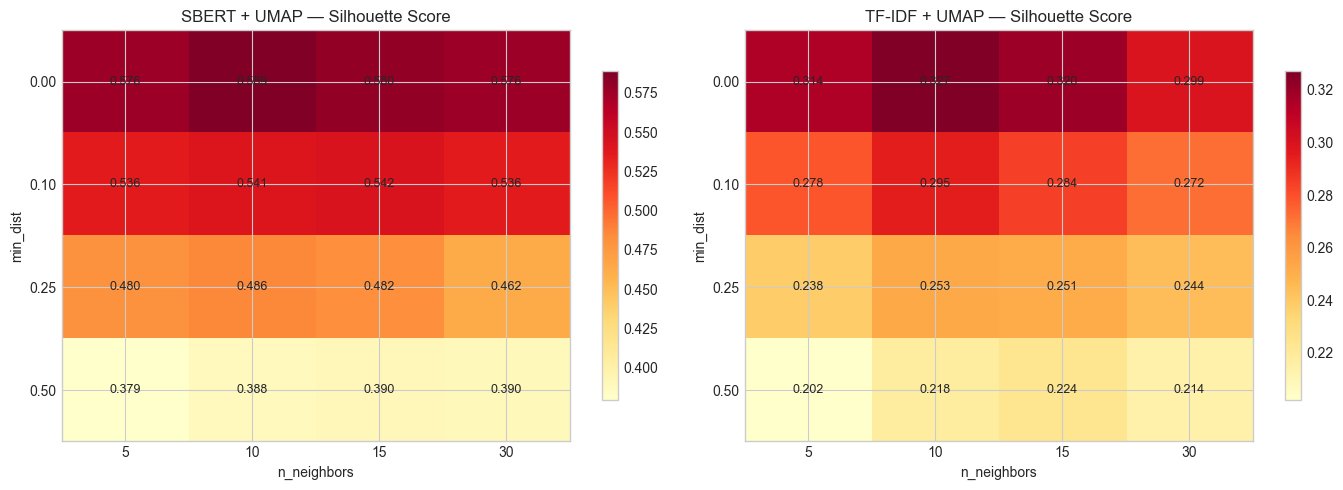

In [5]:
# Visualize grid search results as heatmaps
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, title in [
    (axes[0], results_df, "SBERT + UMAP"),
    (axes[1], results_tfidf_df, "TF-IDF + UMAP")
]:
    pivot = df.pivot(index="min_dist", columns="n_neighbors", values="silhouette")
    im = ax.imshow(pivot.values, cmap="YlOrRd", aspect="auto")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([f"{v:.2f}" for v in pivot.index])
    ax.set_xlabel("n_neighbors")
    ax.set_ylabel("min_dist")
    ax.set_title(f"{title} — Silhouette Score")
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            ax.text(j, i, f"{pivot.values[i, j]:.3f}", ha="center", va="center", fontsize=9)
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.savefig(f"{PROJECT_ROOT}/figures/umap_grid_search.png", dpi=150, bbox_inches="tight")
plt.show()

## 5.2 Apply Best UMAP to Full HumAID Dataset

In [6]:
# Best UMAP params
best_nn_sbert = int(best_sbert["n_neighbors"])
best_md_sbert = float(best_sbert["min_dist"])
best_nn_tfidf = int(best_tfidf["n_neighbors"])
best_md_tfidf = float(best_tfidf["min_dist"])

print(f"Best SBERT UMAP params: n_neighbors={best_nn_sbert}, min_dist={best_md_sbert}")
print(f"Best TF-IDF UMAP params: n_neighbors={best_nn_tfidf}, min_dist={best_md_tfidf}")

Best SBERT UMAP params: n_neighbors=10, min_dist=0.0
Best TF-IDF UMAP params: n_neighbors=10, min_dist=0.0


In [7]:
# SBERT → UMAP 5D (clustering) and 2D (visualization)
print("SBERT → UMAP 5D (full dataset)...")
start = time.time()
umap_sbert_5d = umap.UMAP(
    n_components=5, n_neighbors=best_nn_sbert, min_dist=best_md_sbert,
    metric="cosine", random_state=SEED
).fit_transform(humaid_sbert)
print(f"  Done in {time.time()-start:.1f}s — shape: {umap_sbert_5d.shape}")

print("SBERT → UMAP 2D (full dataset)...")
start = time.time()
umap_sbert_2d = umap.UMAP(
    n_components=2, n_neighbors=best_nn_sbert, min_dist=best_md_sbert,
    metric="cosine", random_state=SEED
).fit_transform(humaid_sbert)
print(f"  Done in {time.time()-start:.1f}s — shape: {umap_sbert_2d.shape}")

np.save(f"{PROJECT_ROOT}/data/embeddings/humaid_umap_sbert_5d.npy", umap_sbert_5d)
np.save(f"{PROJECT_ROOT}/data/embeddings/humaid_umap_sbert_2d.npy", umap_sbert_2d)
print("Saved.")

SBERT → UMAP 5D (full dataset)...


/Users/cyril/Desktop/Un-supervised/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  Done in 36.3s — shape: (76477, 5)
SBERT → UMAP 2D (full dataset)...


/Users/cyril/Desktop/Un-supervised/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  Done in 34.8s — shape: (76477, 2)
Saved.


In [8]:
# TF-IDF → UMAP 5D and 2D
print("TF-IDF → UMAP 5D (full dataset)...")
start = time.time()
umap_tfidf_5d = umap.UMAP(
    n_components=5, n_neighbors=best_nn_tfidf, min_dist=best_md_tfidf,
    metric="cosine", random_state=SEED
).fit_transform(humaid_tfidf)
print(f"  Done in {time.time()-start:.1f}s — shape: {umap_tfidf_5d.shape}")

print("TF-IDF → UMAP 2D (full dataset)...")
start = time.time()
umap_tfidf_2d = umap.UMAP(
    n_components=2, n_neighbors=best_nn_tfidf, min_dist=best_md_tfidf,
    metric="cosine", random_state=SEED
).fit_transform(humaid_tfidf)
print(f"  Done in {time.time()-start:.1f}s — shape: {umap_tfidf_2d.shape}")

np.save(f"{PROJECT_ROOT}/data/embeddings/humaid_umap_tfidf_5d.npy", umap_tfidf_5d)
np.save(f"{PROJECT_ROOT}/data/embeddings/humaid_umap_tfidf_2d.npy", umap_tfidf_2d)
print("Saved.")

TF-IDF → UMAP 5D (full dataset)...


/Users/cyril/Desktop/Un-supervised/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  Done in 74.6s — shape: (76477, 5)
TF-IDF → UMAP 2D (full dataset)...
  Done in 73.1s — shape: (76477, 2)
Saved.


## 5.3 PCA (Linear Baseline for SBERT)

In [9]:
# PCA on SBERT — 50D for clustering, 2D for visualization
print("SBERT → PCA 50D...")
start = time.time()
pca_50 = PCA(n_components=50, random_state=SEED)
pca_sbert_50d = pca_50.fit_transform(humaid_sbert)
print(f"  Done in {time.time()-start:.1f}s — shape: {pca_sbert_50d.shape}")
print(f"  Explained variance (50 components): {pca_50.explained_variance_ratio_.sum():.3f}")

print("SBERT → PCA 2D...")
pca_2 = PCA(n_components=2, random_state=SEED)
pca_sbert_2d = pca_2.fit_transform(humaid_sbert)
print(f"  Explained variance (2 components): {pca_2.explained_variance_ratio_.sum():.3f}")

np.save(f"{PROJECT_ROOT}/data/embeddings/humaid_pca_sbert_50d.npy", pca_sbert_50d)
np.save(f"{PROJECT_ROOT}/data/embeddings/humaid_pca_sbert_2d.npy", pca_sbert_2d)
print("Saved.")

SBERT → PCA 50D...
  Done in 0.1s — shape: (76477, 50)
  Explained variance (50 components): 0.626
SBERT → PCA 2D...
  Explained variance (2 components): 0.107
Saved.


## 5.4 TruncatedSVD (Linear Baseline for TF-IDF)

In [10]:
# TruncatedSVD on TF-IDF — 50D for clustering, 2D for visualization
print("TF-IDF → TruncatedSVD 50D...")
start = time.time()
svd_50 = TruncatedSVD(n_components=50, random_state=SEED)
svd_tfidf_50d = svd_50.fit_transform(humaid_tfidf)
print(f"  Done in {time.time()-start:.1f}s — shape: {svd_tfidf_50d.shape}")
print(f"  Explained variance (50 components): {svd_50.explained_variance_ratio_.sum():.3f}")

print("TF-IDF → TruncatedSVD 2D...")
svd_2 = TruncatedSVD(n_components=2, random_state=SEED)
svd_tfidf_2d = svd_2.fit_transform(humaid_tfidf)
print(f"  Explained variance (2 components): {svd_2.explained_variance_ratio_.sum():.3f}")

np.save(f"{PROJECT_ROOT}/data/embeddings/humaid_svd_tfidf_50d.npy", svd_tfidf_50d)
np.save(f"{PROJECT_ROOT}/data/embeddings/humaid_svd_tfidf_2d.npy", svd_tfidf_2d)
print("Saved.")

TF-IDF → TruncatedSVD 50D...
  Done in 0.7s — shape: (76477, 50)
  Explained variance (50 components): 0.108
TF-IDF → TruncatedSVD 2D...
  Explained variance (2 components): 0.007
Saved.


## 5.5 t-SNE (Visualization Only — Sampled Subset)

In [11]:
# t-SNE on a 10K sample (too slow for full 76K)
tsne_sample_idx = np.random.choice(len(humaid_sbert), size=10000, replace=False)
tsne_sample_labels = humaid["class_label"].values[tsne_sample_idx]

print("SBERT sample → t-SNE 2D (10K tweets, perplexity=30)...")
start = time.time()
tsne_sbert_2d = TSNE(
    n_components=2, perplexity=30, random_state=SEED, max_iter=1000
).fit_transform(humaid_sbert[tsne_sample_idx])
print(f"  Done in {time.time()-start:.1f}s")

print("TF-IDF sample → t-SNE 2D (10K tweets, perplexity=30)...")
start = time.time()
# t-SNE needs dense input
tfidf_dense_sample = humaid_tfidf[tsne_sample_idx].toarray()
tsne_tfidf_2d = TSNE(
    n_components=2, perplexity=30, random_state=SEED, max_iter=1000
).fit_transform(tfidf_dense_sample)
print(f"  Done in {time.time()-start:.1f}s")

# Save for later visualization
np.save(f"{PROJECT_ROOT}/data/embeddings/tsne_sbert_2d_10k.npy", tsne_sbert_2d)
np.save(f"{PROJECT_ROOT}/data/embeddings/tsne_tfidf_2d_10k.npy", tsne_tfidf_2d)
np.save(f"{PROJECT_ROOT}/data/embeddings/tsne_sample_idx.npy", tsne_sample_idx)
print("Saved.")

SBERT sample → t-SNE 2D (10K tweets, perplexity=30)...
  Done in 21.1s
TF-IDF sample → t-SNE 2D (10K tweets, perplexity=30)...
  Done in 32.0s
Saved.


## 5.6 Visualization Comparison

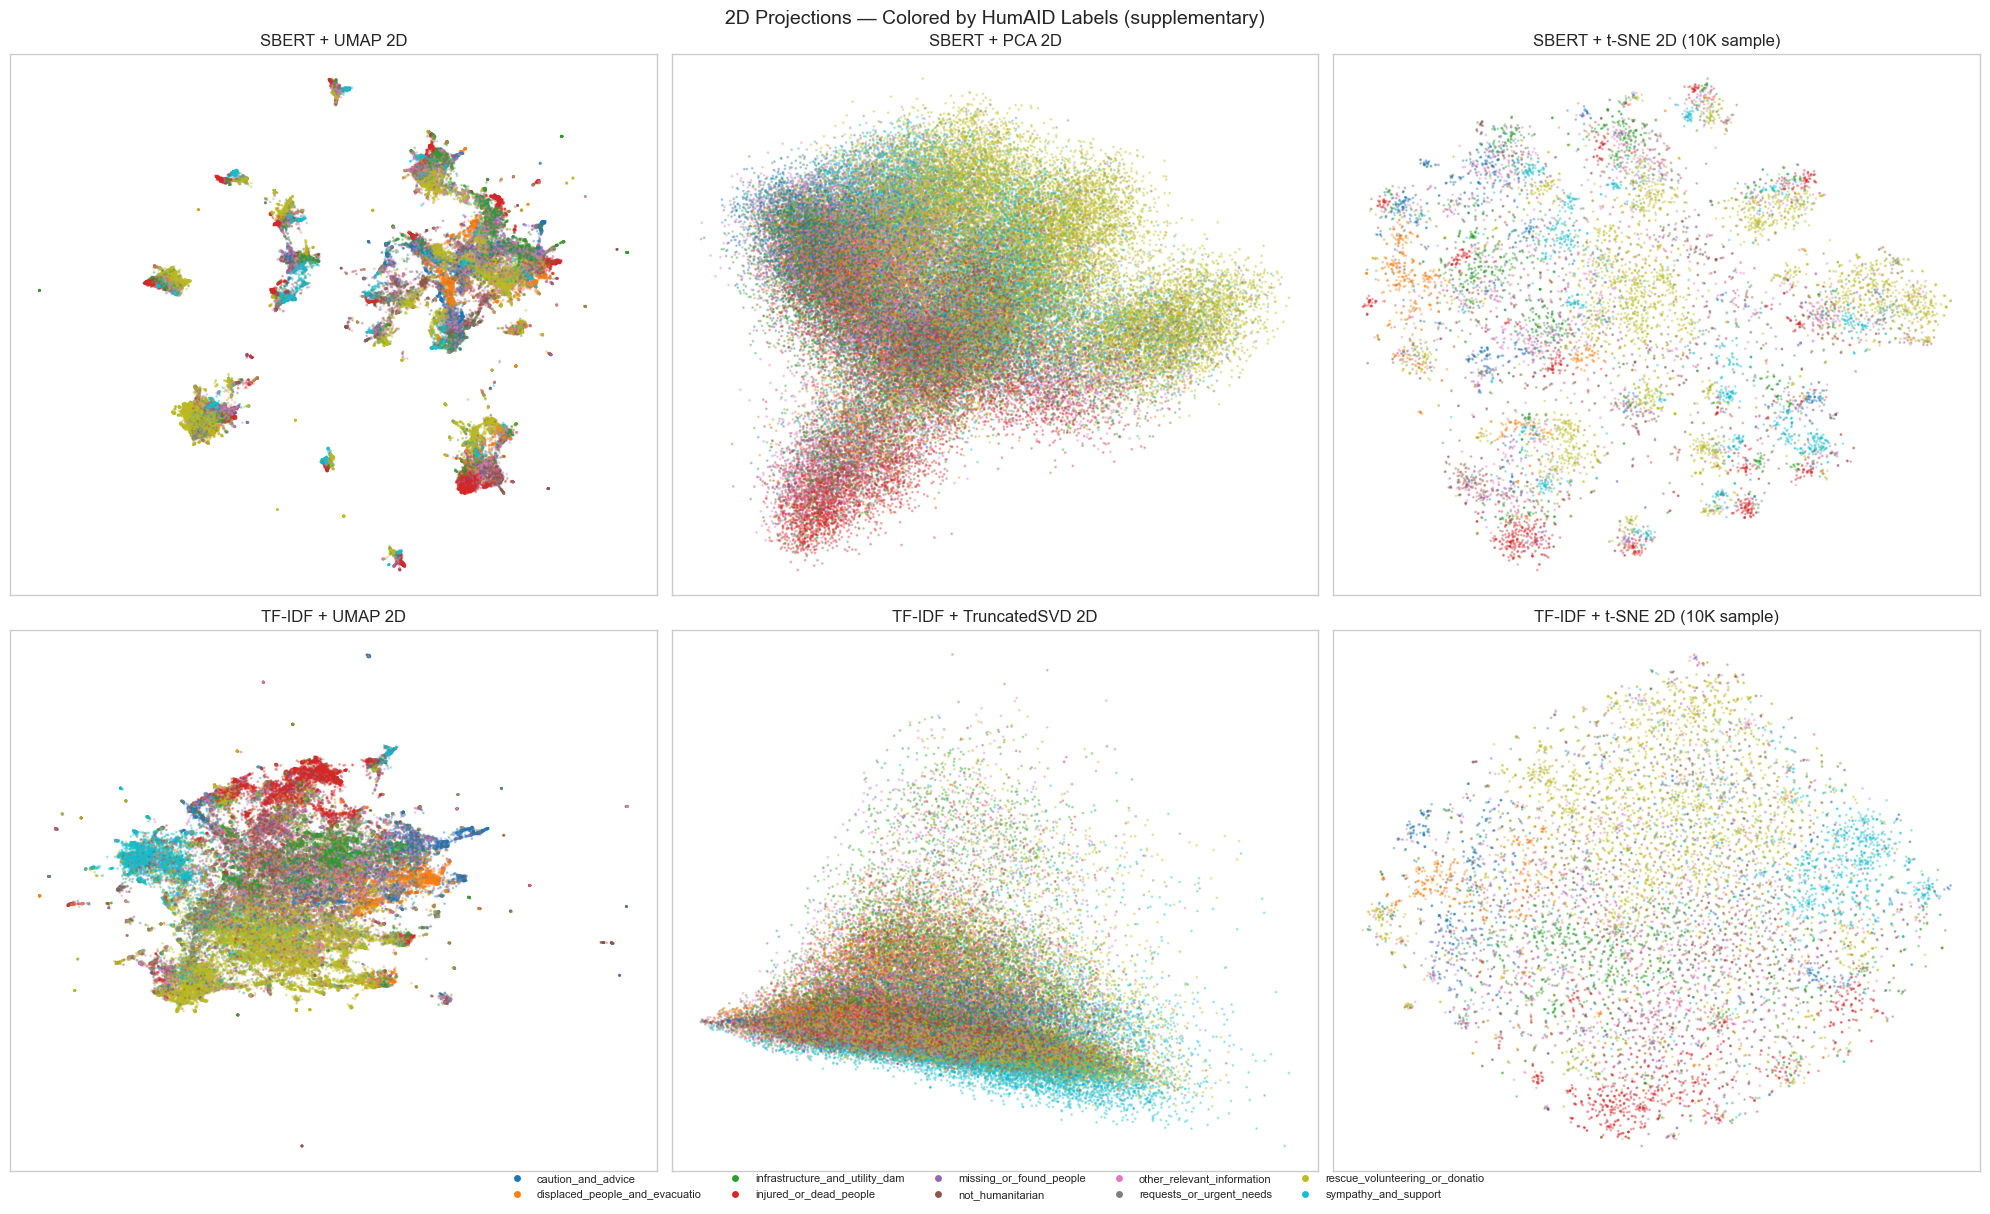

In [12]:
# Compare 2D projections side by side
# Use class labels for coloring (supplementary only — not used for training)
labels_full = humaid["class_label"].values
unique_labels = sorted(humaid["class_label"].unique())
label_to_int = {l: i for i, l in enumerate(unique_labels)}
colors_full = np.array([label_to_int[l] for l in labels_full])
colors_sample = np.array([label_to_int[l] for l in tsne_sample_labels])

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

projections = [
    (axes[0, 0], umap_sbert_2d, colors_full, "SBERT + UMAP 2D"),
    (axes[0, 1], pca_sbert_2d, colors_full, "SBERT + PCA 2D"),
    (axes[0, 2], tsne_sbert_2d, colors_sample, "SBERT + t-SNE 2D (10K sample)"),
    (axes[1, 0], umap_tfidf_2d, colors_full, "TF-IDF + UMAP 2D"),
    (axes[1, 1], svd_tfidf_2d, colors_full, "TF-IDF + TruncatedSVD 2D"),
    (axes[1, 2], tsne_tfidf_2d, colors_sample, "TF-IDF + t-SNE 2D (10K sample)"),
]

for ax, data, colors, title in projections:
    scatter = ax.scatter(data[:, 0], data[:, 1], c=colors, cmap="tab10",
                         s=1, alpha=0.3, rasterized=True)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])

# Add legend
handles = [plt.Line2D([0], [0], marker='o', color='w',
           markerfacecolor=plt.cm.tab10(label_to_int[l] / 10), markersize=6, label=l[:30])
           for l in unique_labels]
fig.legend(handles=handles, loc='lower center', ncol=5, fontsize=8,
           bbox_to_anchor=(0.5, -0.02))

plt.suptitle("2D Projections — Colored by HumAID Labels (supplementary)", fontsize=14)
plt.tight_layout()
plt.savefig(f"{PROJECT_ROOT}/figures/dim_reduction_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 5.7 Save UMAP Config & Summary

In [13]:
import yaml

# Save best UMAP parameters to config
umap_config = {
    "umap_sbert": {
        "n_neighbors": best_nn_sbert,
        "min_dist": best_md_sbert,
        "metric": "cosine",
        "silhouette_score": float(best_sbert["silhouette"])
    },
    "umap_tfidf": {
        "n_neighbors": best_nn_tfidf,
        "min_dist": best_md_tfidf,
        "metric": "cosine",
        "silhouette_score": float(best_tfidf["silhouette"])
    },
    "pca_sbert": {
        "n_components_cluster": 50,
        "explained_variance_50d": float(pca_50.explained_variance_ratio_.sum()),
        "explained_variance_2d": float(pca_2.explained_variance_ratio_.sum())
    },
    "svd_tfidf": {
        "n_components_cluster": 50,
        "explained_variance_50d": float(svd_50.explained_variance_ratio_.sum()),
        "explained_variance_2d": float(svd_2.explained_variance_ratio_.sum())
    },
    "random_seed": SEED
}

os.makedirs(f"{PROJECT_ROOT}/config", exist_ok=True)
with open(f"{PROJECT_ROOT}/config/dim_reduction_config.yaml", "w") as f:
    yaml.dump(umap_config, f, default_flow_style=False)

print("Dimensionality Reduction Config:")
print(yaml.dump(umap_config, default_flow_style=False))

Dimensionality Reduction Config:
pca_sbert:
  explained_variance_2d: 0.10677462071180344
  explained_variance_50d: 0.6262573599815369
  n_components_cluster: 50
random_seed: 42
svd_tfidf:
  explained_variance_2d: 0.007316806225154994
  explained_variance_50d: 0.10802196604213347
  n_components_cluster: 50
umap_sbert:
  metric: cosine
  min_dist: 0.0
  n_neighbors: 10
  silhouette_score: 0.5885214805603027
umap_tfidf:
  metric: cosine
  min_dist: 0.0
  n_neighbors: 10
  silhouette_score: 0.32700297236442566



In [14]:
# Summary of saved files
print("Saved dimensionality reduction outputs:")
emb_dir = f"{PROJECT_ROOT}/data/embeddings"
for f in sorted(os.listdir(emb_dir)):
    if any(k in f for k in ["umap", "pca", "svd", "tsne"]):
        path = os.path.join(emb_dir, f)
        size_mb = os.path.getsize(path) / (1024 * 1024)
        print(f"  {f}: {size_mb:.1f} MB")

print(f"\nReduced representations ready for clustering:")
print(f"  SBERT + UMAP 5D:        {umap_sbert_5d.shape}")
print(f"  SBERT + PCA 50D:        {pca_sbert_50d.shape}")
print(f"  TF-IDF + UMAP 5D:       {umap_tfidf_5d.shape}")
print(f"  TF-IDF + TruncatedSVD 50D: {svd_tfidf_50d.shape}")
print(f"\nNext step: Run 06_clustering.ipynb for HDBSCAN, K-Means, and Agglomerative clustering.")

Saved dimensionality reduction outputs:
  humaid_pca_sbert_2d.npy: 0.6 MB
  humaid_pca_sbert_50d.npy: 14.6 MB
  humaid_svd_tfidf_2d.npy: 1.2 MB
  humaid_svd_tfidf_50d.npy: 29.2 MB
  humaid_umap_sbert_2d.npy: 0.6 MB
  humaid_umap_sbert_5d.npy: 1.5 MB
  humaid_umap_tfidf_2d.npy: 0.6 MB
  humaid_umap_tfidf_5d.npy: 1.5 MB
  tsne_sample_idx.npy: 0.1 MB
  tsne_sbert_2d_10k.npy: 0.1 MB
  tsne_tfidf_2d_10k.npy: 0.1 MB

Reduced representations ready for clustering:
  SBERT + UMAP 5D:        (76477, 5)
  SBERT + PCA 50D:        (76477, 50)
  TF-IDF + UMAP 5D:       (76477, 5)
  TF-IDF + TruncatedSVD 50D: (76477, 50)

Next step: Run 06_clustering.ipynb for HDBSCAN, K-Means, and Agglomerative clustering.
